# Neural Network Regression with Different Loss Functions

이번 실습에서는 TensorFlow를 활용하여 Neural Network 회귀 모델을 만들고,
다양한 손실 함수 (MSE, MAE, Huber Loss)를 적용하여 비교해봅니다.

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# matplotlib 폰트 깨짐 현상 해결
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # Enable negative sign for Korean fonts

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,183 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126435 files and dire

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. 데이터 불러오기 및 전처리

In [3]:
# 1. 데이터 불러오기
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 2. train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 데이터 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. 모델 정의 함수

In [4]:
def build_model(loss_fn):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=X_train.shape[1:]),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)   # 회귀 출력
    ])
    model.compile(optimizer="adam", loss=loss_fn, metrics=["mae"])
    return model

## 3. 손실 함수별 학습 (MSE, MAE, Huber Loss)

In [5]:
loss_functions = {
    "MSE": "mse",
    "MAE": "mae",
    "Huber": tf.keras.losses.Huber()
}

histories = {}

for name, loss_fn in loss_functions.items():
    print(f"\n=== Training with {name} Loss ===")
    model = build_model(loss_fn)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=32,
        verbose=2
    )
    histories[name] = history


=== Training with MSE Loss ===
Epoch 1/20
516/516 - 2s - 5ms/step - loss: 0.7312 - mae: 0.5806 - val_loss: 0.4647 - val_mae: 0.4714
Epoch 2/20
516/516 - 2s - 3ms/step - loss: 0.3938 - mae: 0.4466 - val_loss: 0.3883 - val_mae: 0.4397
Epoch 3/20
516/516 - 3s - 5ms/step - loss: 0.3639 - mae: 0.4286 - val_loss: 0.3638 - val_mae: 0.4316
Epoch 4/20
516/516 - 3s - 5ms/step - loss: 0.3514 - mae: 0.4188 - val_loss: 0.3796 - val_mae: 0.4197
Epoch 5/20
516/516 - 3s - 5ms/step - loss: 0.3471 - mae: 0.4093 - val_loss: 0.3506 - val_mae: 0.4050
Epoch 6/20
516/516 - 2s - 4ms/step - loss: 0.3298 - mae: 0.4016 - val_loss: 0.3374 - val_mae: 0.4053
Epoch 7/20
516/516 - 1s - 2ms/step - loss: 0.3220 - mae: 0.3964 - val_loss: 0.3303 - val_mae: 0.3961
Epoch 8/20
516/516 - 1s - 2ms/step - loss: 0.3155 - mae: 0.3919 - val_loss: 0.3288 - val_mae: 0.3970
Epoch 9/20
516/516 - 2s - 3ms/step - loss: 0.3110 - mae: 0.3886 - val_loss: 0.3214 - val_mae: 0.3926
Epoch 10/20
516/516 - 2s - 3ms/step - loss: 0.3143 - mae: 0

## 4. 학습 결과 시각화

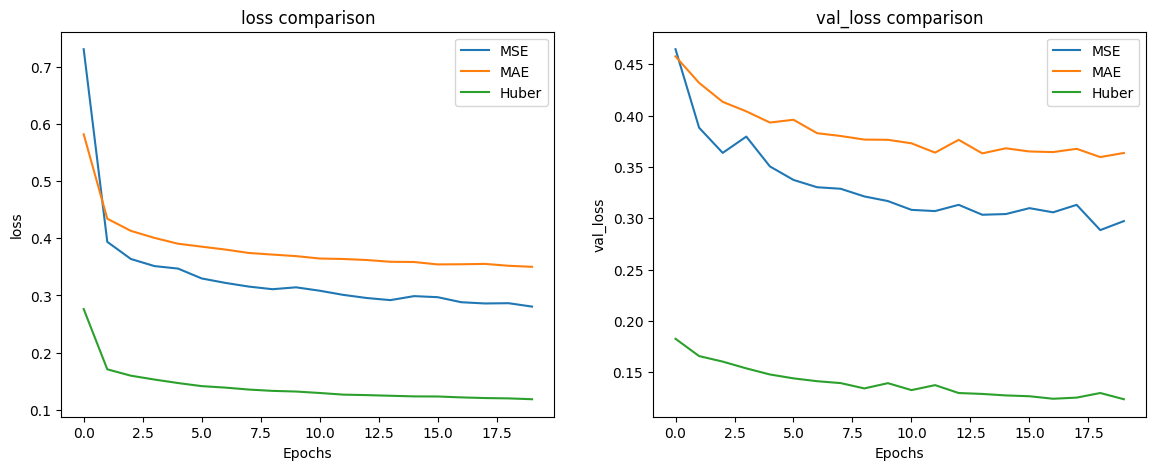

In [6]:
plt.figure(figsize=(14,5))

for i, metric in enumerate(["loss", "val_loss"]):
    plt.subplot(1, 2, i+1)
    for name, history in histories.items():
        plt.plot(history.history[metric], label=f"{name}")
    plt.title(f"{metric} comparison")
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend()

plt.show()